# T-maze

**Objective:** Compare hyperparameters and evaluate spatial features pyramidal neurons learn to encode.

* T-maze
* Agent navigation is largely fixed based on a randomly selected target arm for each trajectory.
* Target object initially located near end of one arm.
* Two-compartment pyramidal neuron layer:
  * Somatic input: jittered, but uniformly distributed Gaussian place cells (plastic)
  * Dendritic input: Target object-encoding cell (fixed)
  * Filtered dendritic self-inhibition
  * 1 pyramidal neuron only
* Learning:
  * BTSP learning: strong learning with a broad kernel, occurring when a neuron's activation passes a predetermined threshold.

In [1]:
import copy
from typing import Any
import warnings

from matplotlib import pyplot as plt
import numpy as np
import ratinabox
from tqdm import tqdm

from predhpc import agent, env, run_manager, plot_fcts
from predhpc.neurons import learning_neurons, two_comp_neurons, object_neurons
from predhpc.util import plot_util, params_util

In [2]:
plot_util.stylize_plots_for_notebook()
ratinabox.autosave_plots = False
ratinabox.figure_directory = "figures"

In [3]:
warnings.filterwarnings(
    "ignore", message="invalid value encountered", 
    category=RuntimeWarning
)

In [4]:
import importlib
importlib.reload(agent)
importlib.reload(env)
importlib.reload(learning_neurons)
importlib.reload(two_comp_neurons)
importlib.reload(object_neurons)
importlib.reload(run_manager)
importlib.reload(plot_util)
importlib.reload(params_util);

## 1. Initial target location

In [13]:
BTSP_LR_FACT = 150
# BTSP_LR_FACT = 40 # low factor
ALPHA_REG = 0.6 # lower regularization

env_params = params_util.get_env_params(environment="tmaze")

agent_params = params_util.get_agent_params(
    environment="tmaze", left_arm_prop=0.8
)

PC_params = params_util.get_PC_params(
    environment="tmaze", place_cell_centres="uniform"
)

Pyr_params = params_util.get_Pyr_params(
    n=1, environment="tmaze", 
    two_compartment=True, BTSP=True,
    soma_BTSP_lr_fact=BTSP_LR_FACT,
    soma_regularization_alpha=ALPHA_REG,
)

array([<Axes: >, <Axes: >, <Axes: >], dtype=object)

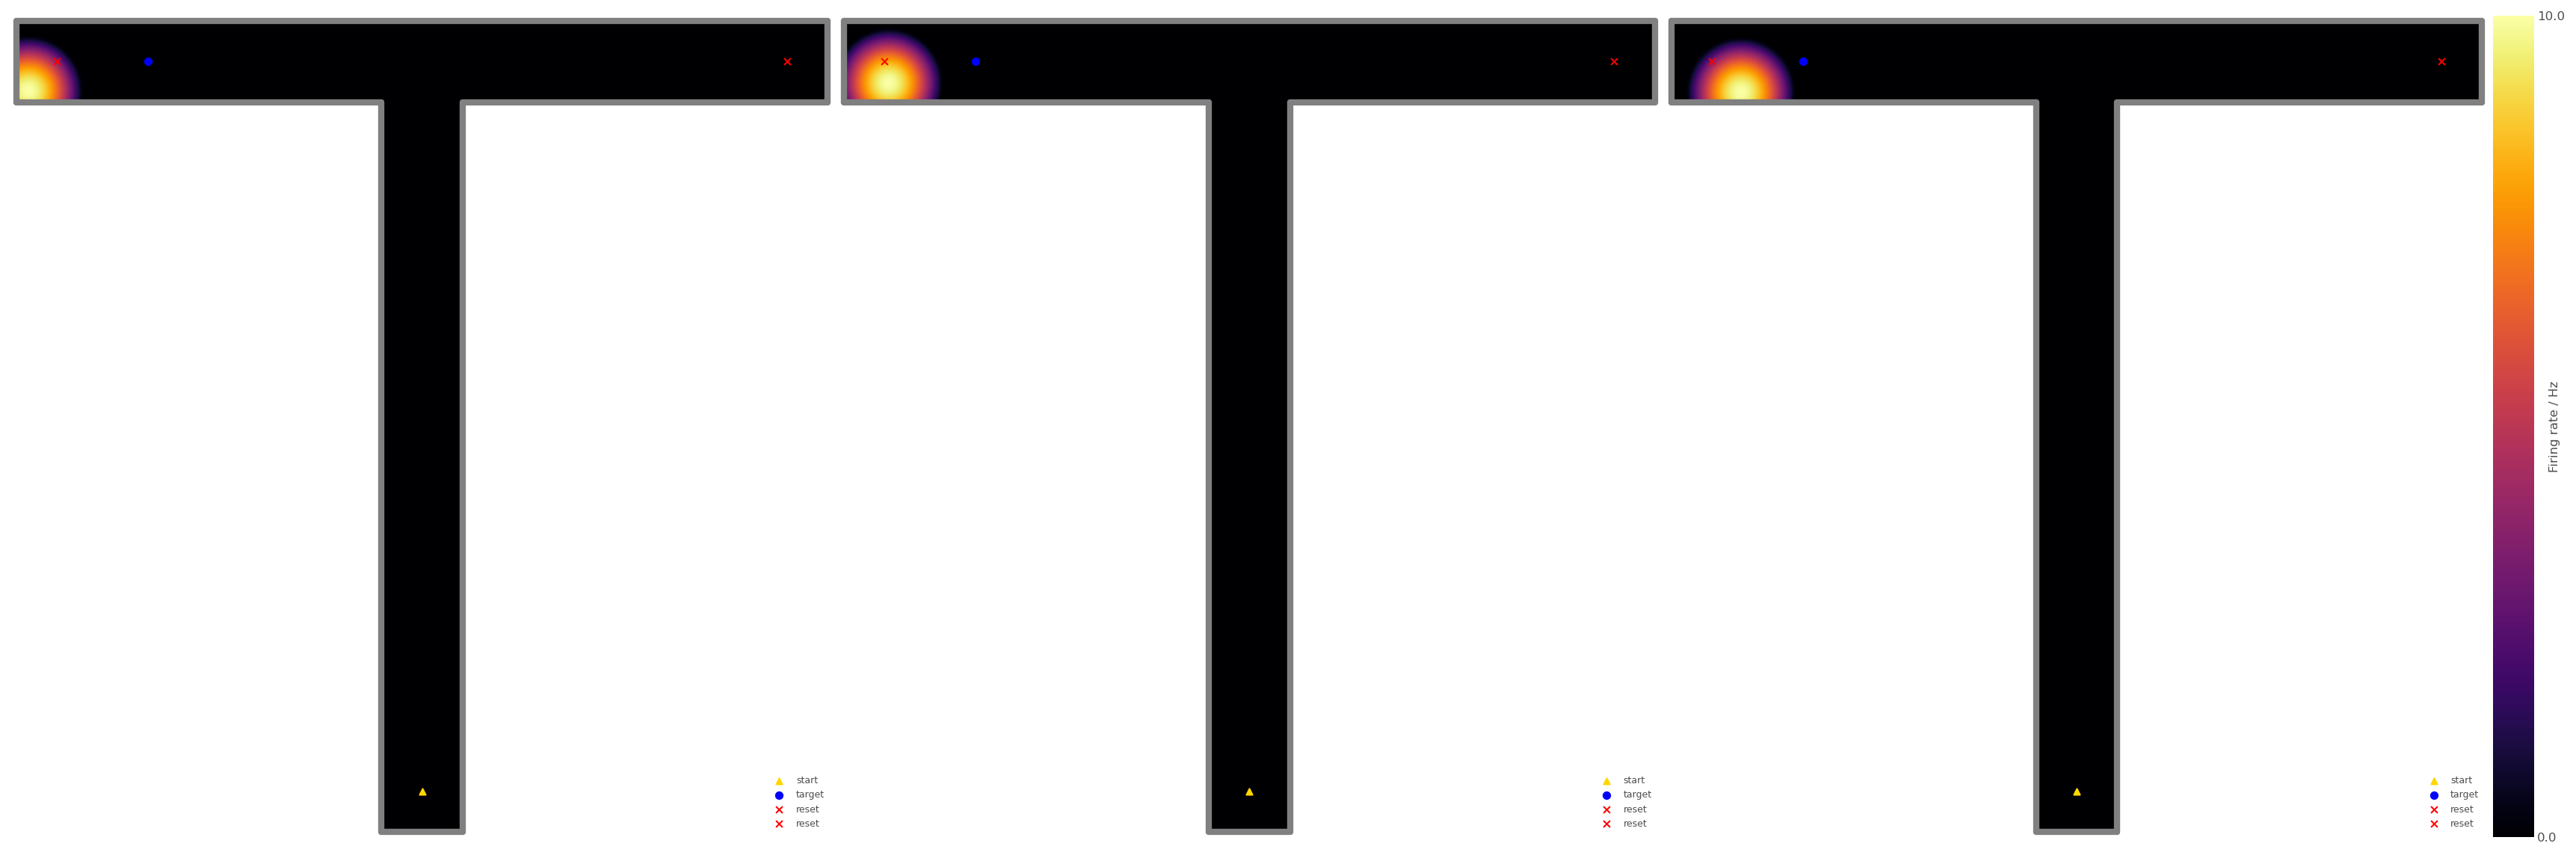

In [26]:
PCs.plot_rate_map(chosen_neurons=[0, 1, 2])

100%|██████████████████████████████████████████| 10/10 [00:00<00:00, 481.05it/s]


Only reached the reward 0 times (target: 8).
Trajectory lengths (1) to date: 0.30 +/- 0.00 sec each
Trajectory lengths (1) to date: 10.00 +/- 0.00 steps each


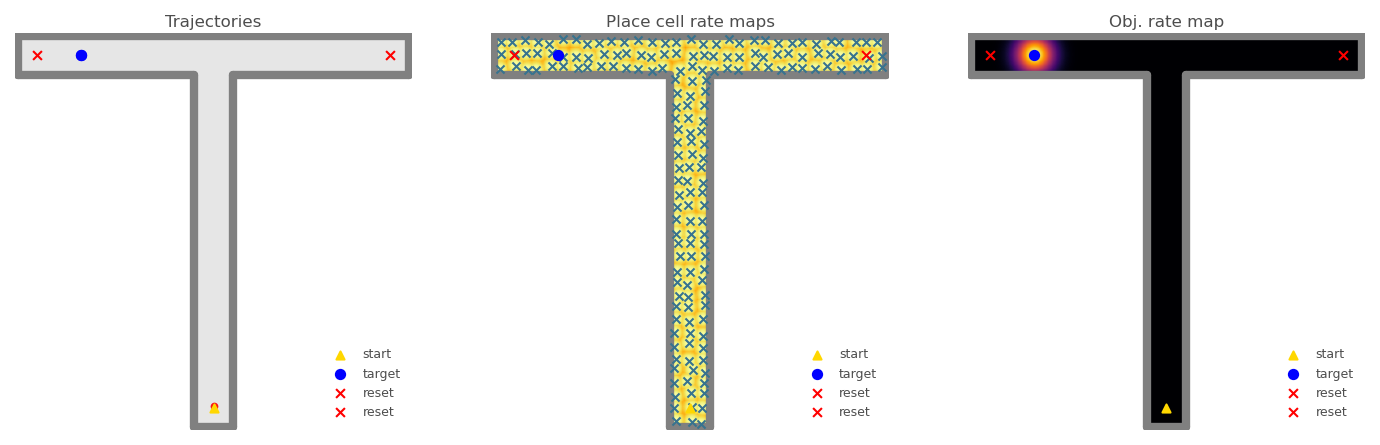

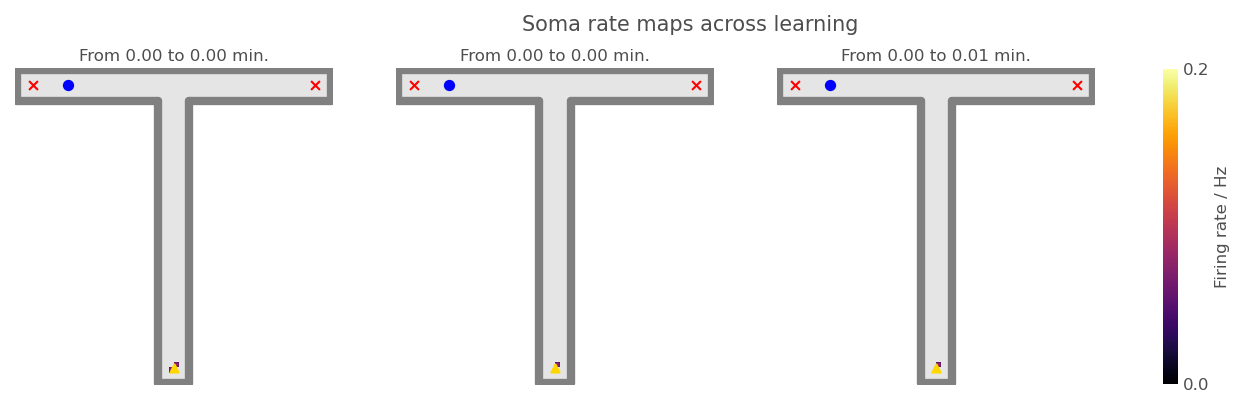

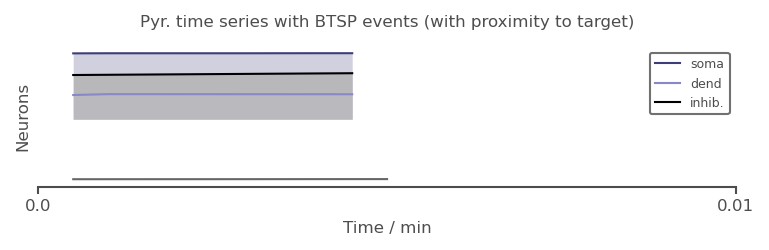

In [15]:
PC_params = params_util.get_PC_params(
    environment="tmaze", 
    n= 177, # 40, # for one column and one row 
    place_cell_centres="uniform_jitter"
)

Pyrs = run_manager.learn_T_maze_BTSP(
    env_params=env_params, 
    agent_params=agent_params, 
    PC_params=PC_params, 
    Pyr_params=Pyr_params, 
    num_rewards=8, 
    max_num_steps=10, #4000, 
    weight_recording_freq=100, 
    use_Hebbian=False,
    BTSP_after_num_target_reaches=1,
    two_compartment=True
)

_, Ag, PCs, Pyrs, Objs = run_manager.extract_objects_from_Pyrs(Pyrs)

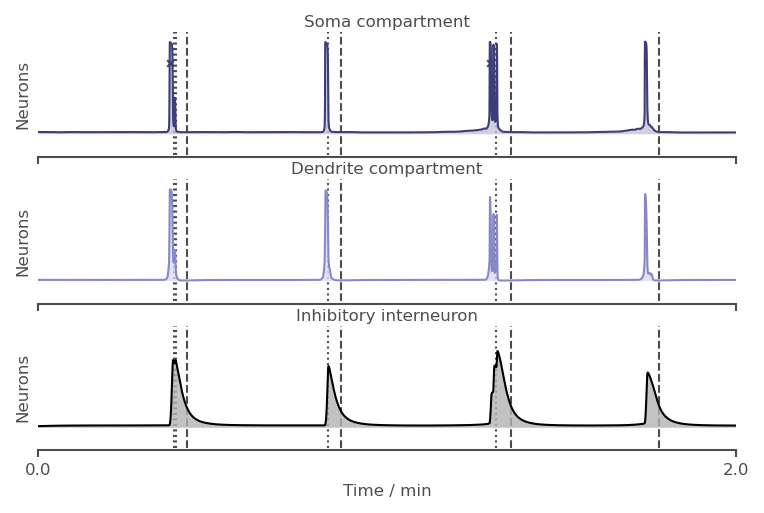

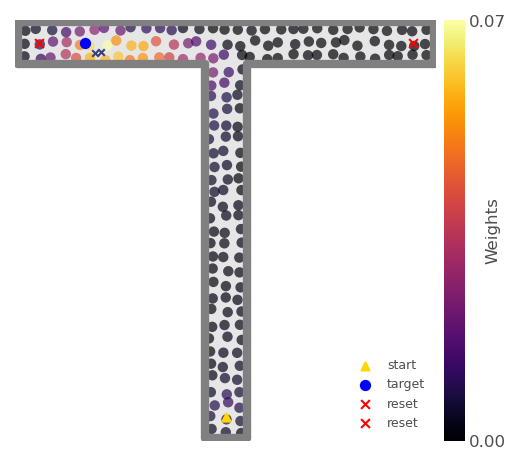

In [7]:
Pyrs.plot_rate_timeseries(separate_axes=True, norm_by="shared_max")

fig, ax = plt.subplots(figsize=[3, 3])
plot_fcts.plot_2D_input_place_cell_weights(Pyrs.SomaCompartment, ax=ax, s=25, plot_BTSP_events=True);

BTSP events applied after 1074.00 steps (32.22 sec.) (num steps: 1074, 1074).


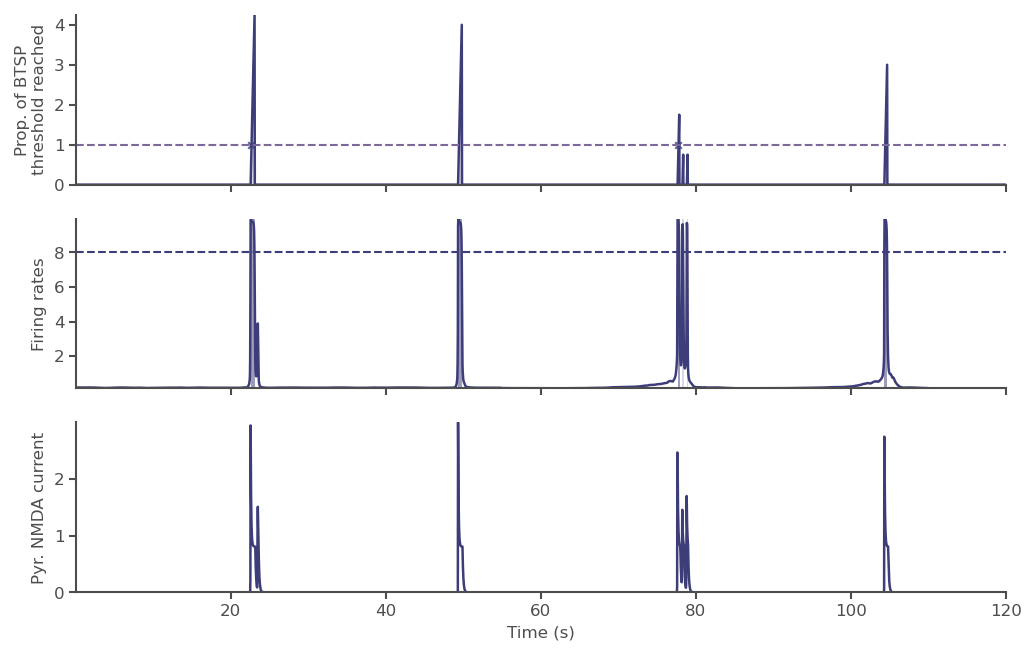

In [8]:
Pyrs.SomaCompartment.log_num_steps_to_apply_BTSP()
Pyrs.SomaCompartment.plot_BTSP_ramp();

BTSP events applied after 1074.00 steps (32.22 sec.) (num steps: 1074).


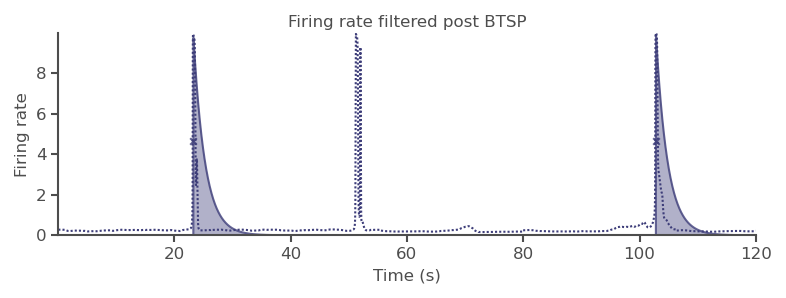

In [32]:
Pyrs.SomaCompartment.plot_filtered_for_BTSP();

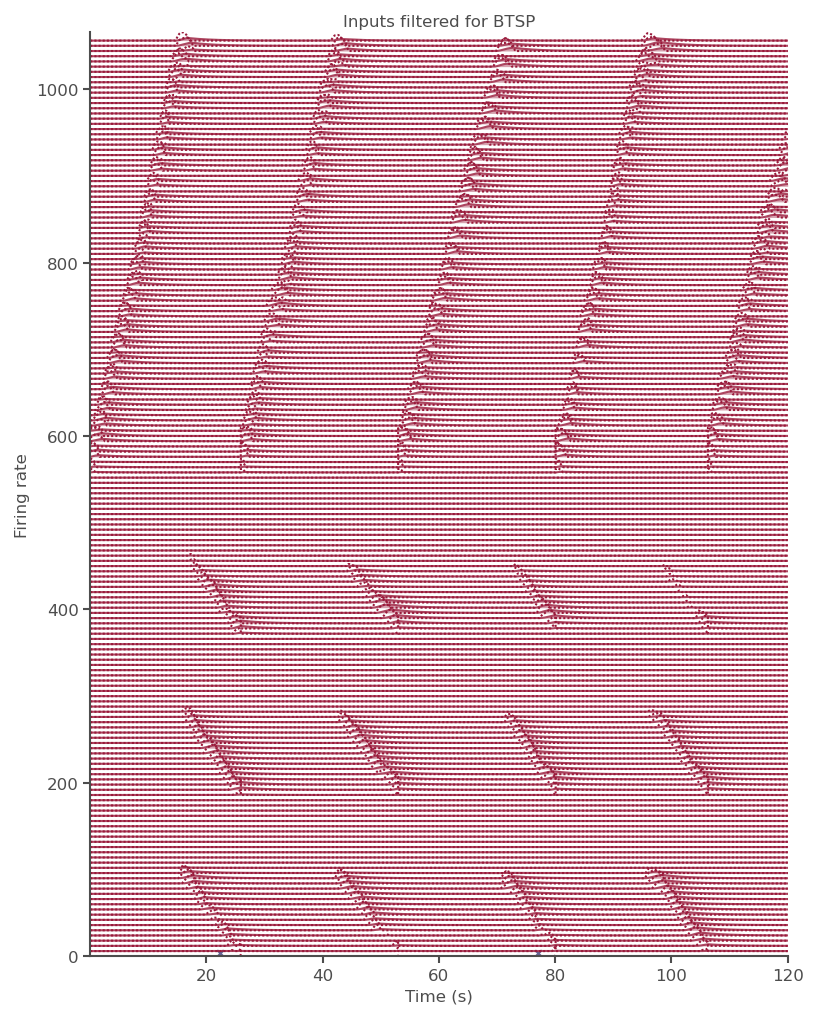

In [10]:
Pyrs.SomaCompartment.plot_filtered_for_BTSP("PCs");

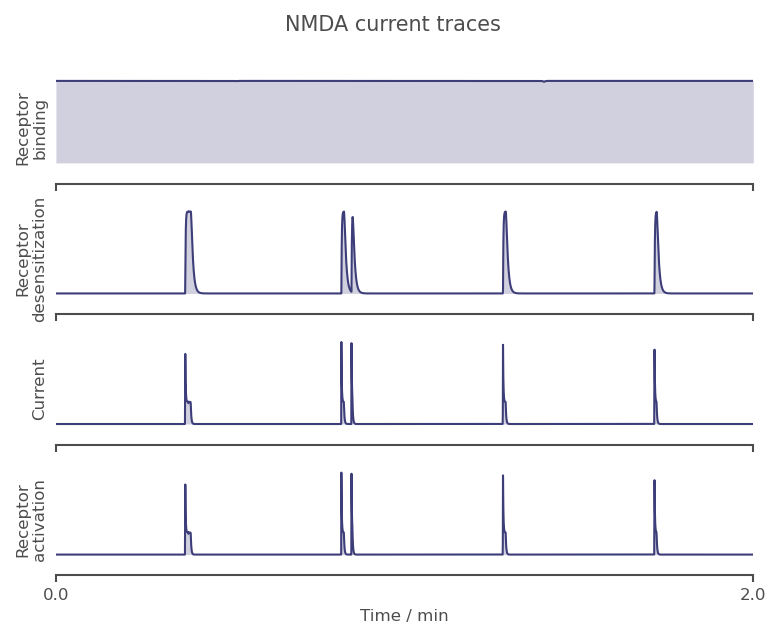

In [11]:
Pyrs.SomaCompartment.inputs["NMDACurrent"]["layer"].plot_timeseries(datatypes="all");

In [12]:
Ag.target_df

,target_arm,position_x,position_y,set_step,set_time,reached_step,reached_time,num_steps_total,time_total
0,left,0.4875,2.85,0,0.00,766.0,22.98,766.0,22.98
1,left,0.4875,2.85,766,22.98,777.0,23.31,11.0,0.33
2,left,0.4875,2.85,777,23.31,NaN,NaN,NaN,NaN


In [13]:
Ag.trajectory_df

,start_position_x,start_position_y,start_step,start_time,stop_position_x,stop_position_y,stop_step,stop_time,num_steps_total,time_total
0,1.500729,0.150806,0,0.00,0.148828,2.888048,864.0,25.92,864.0,25.92
1,1.499053,0.150152,864,25.92,0.185411,2.888048,1766.0,52.98,902.0,27.06
2,1.499104,0.150229,1766,52.98,0.189993,2.888048,2669.0,80.07,903.0,27.09
3,1.499445,0.149111,2669,80.07,0.169106,2.888048,3542.0,106.26,873.0,26.19
4,1.499831,0.149889,3542,106.26,NaN,NaN,NaN,NaN,NaN,NaN


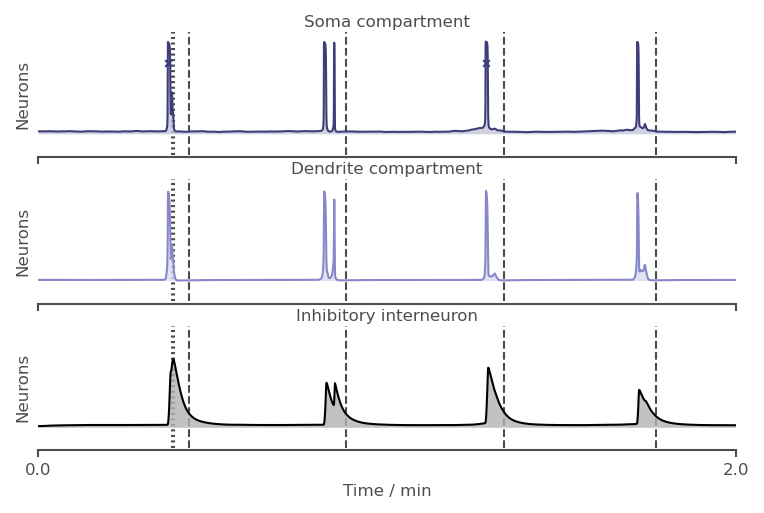

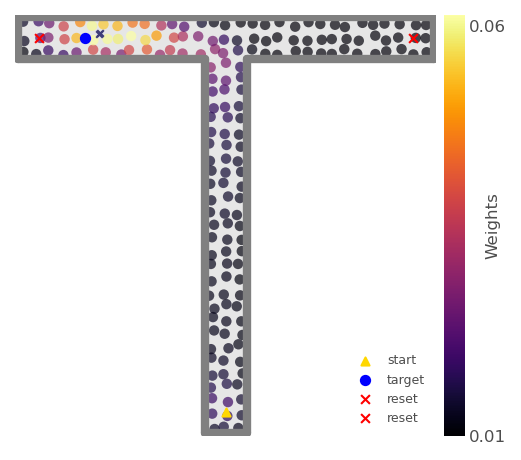

In [14]:
ax_time = Pyrs.plot_rate_timeseries(separate_axes=True, norm_by="shared_max")

fig_weights, ax_weights = plt.subplots(figsize=[3, 3])
plot_fcts.plot_2D_input_place_cell_weights(Pyrs.SomaCompartment, ax=ax_weights, s=25, plot_BTSP_events=True);

## 2. Move target

In [15]:
_, Ag, PCs, Pyrs, Objs = run_manager.extract_objects_from_Pyrs(Pyrs)

Pyrs.Agent.set_target_position([1, 1.3])

In [16]:
num_steps = 2500
for i in tqdm(range(2500)):
    Ag.update(speed_fact=3, drift_to_random_strength_ratio=1)
    Objs.update()
    PCs.update()
    Pyrs.update()

100%|██████████████████████████████████████| 2500/2500 [00:04<00:00, 515.47it/s]


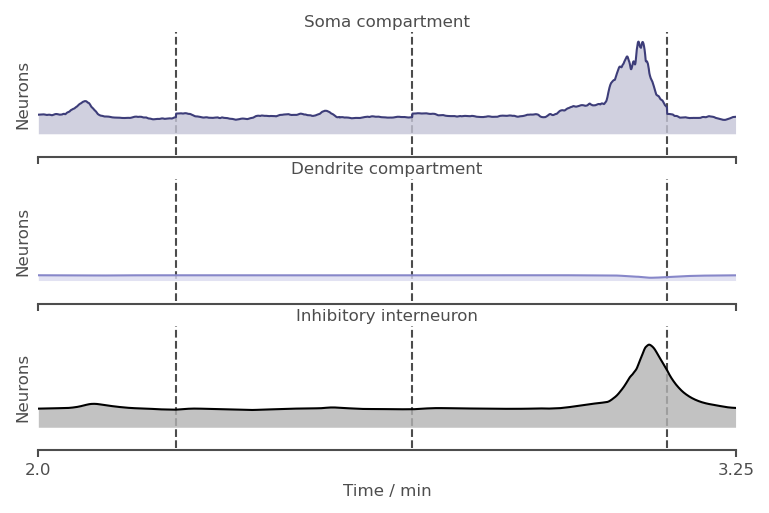

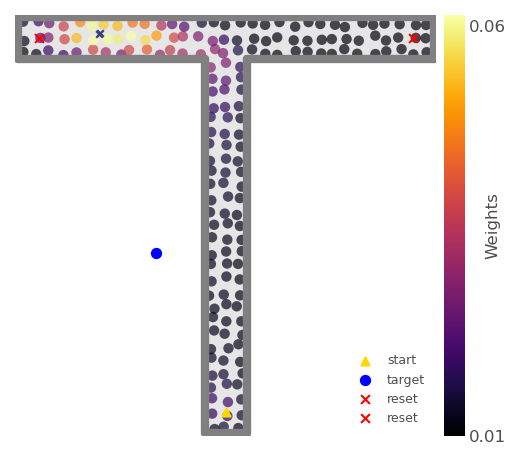

In [17]:
ax_time = Pyrs.plot_rate_timeseries(t_start=2*60, separate_axes=True, norm_by="shared_max")

fig_weights, ax_weights = plt.subplots(figsize=[3, 3])
plot_fcts.plot_2D_input_place_cell_weights(Pyrs.SomaCompartment, ax=ax_weights, s=25, plot_BTSP_events=True);

## 3. Test inhibition hyperparameter

### a. Insufficient dendritic self-inhibition
Multiple BTSP events is similar locations

In [18]:
INHIBIT_WEIGHT = 0.5

In [19]:
DT = params_util.DT

env_params = params_util.get_env_params(environment="tmaze")

agent_params = params_util.get_agent_params(
    environment="tmaze", dt=DT, left_arm_prop=0.8
)

PC_params = params_util.get_PC_params(
    environment="tmaze", place_cell_centres="uniform"
)

Pyr_params = params_util.get_Pyr_params(
    n=1, environment="tmaze", 
    two_compartment=True, BTSP=True,
    soma_BTSP_lr_fact=BTSP_LR_FACT,
    inhibit_weight=INHIBIT_WEIGHT
)

100%|██████████████████████████████████████| 6000/6000 [00:12<00:00, 498.70it/s]


Only reached the reward 4 times (target: 12).
Trajectory lengths (6) to date: 30.00 +/- 10.30 sec each
Trajectory lengths (6) to date: 1000.00 +/- 343.33 steps each


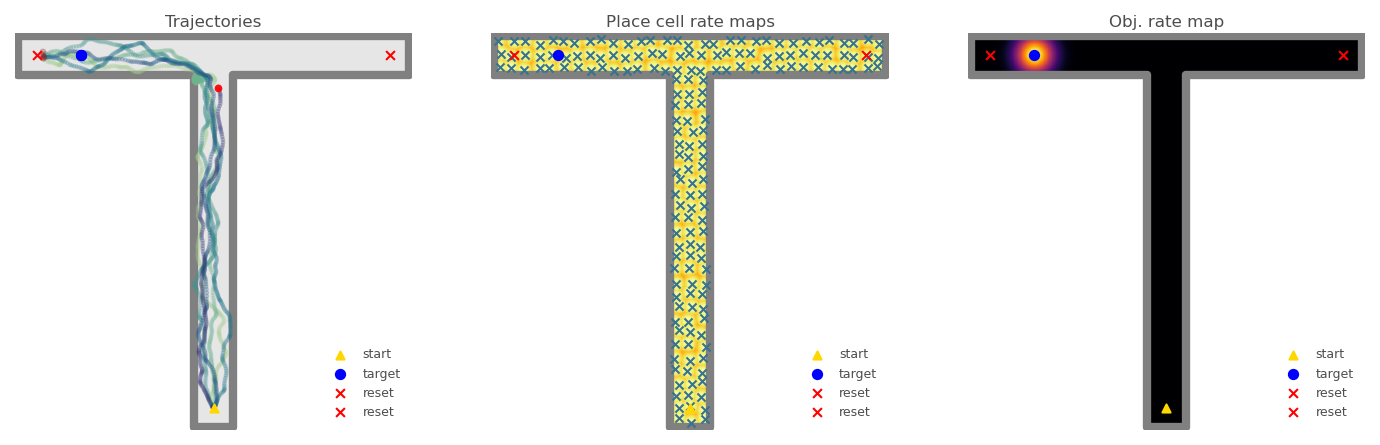

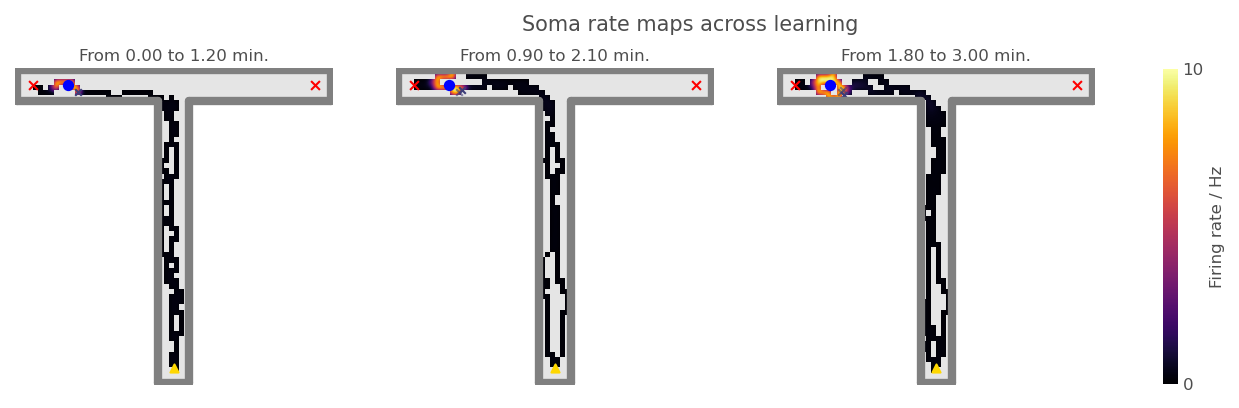

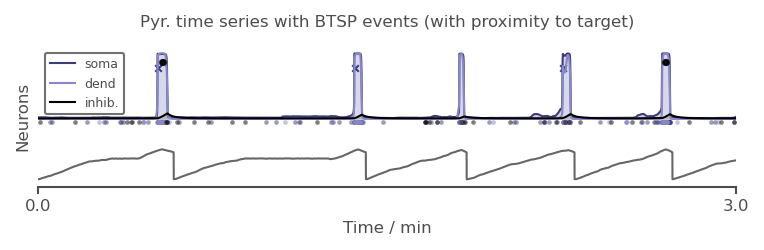

In [20]:
PC_params = params_util.get_PC_params(
    environment="tmaze", 
    n=177, # 40, # for one column and one row 
    place_cell_centres="uniform_jitter"
)

Pyrs = run_manager.learn_T_maze_BTSP(
    env_params=env_params, 
    agent_params=agent_params, 
    PC_params=PC_params, 
    Pyr_params=Pyr_params, 
    num_rewards=12, 
    max_num_steps=6000, 
    weight_recording_freq=100, 
    use_Hebbian=False,
    BTSP_after_num_target_reaches=2, # ignored if 2-compartment
    two_compartment=True
)

_, Ag, PCs, Pyrs, Objs = run_manager.extract_objects_from_Pyrs(Pyrs)

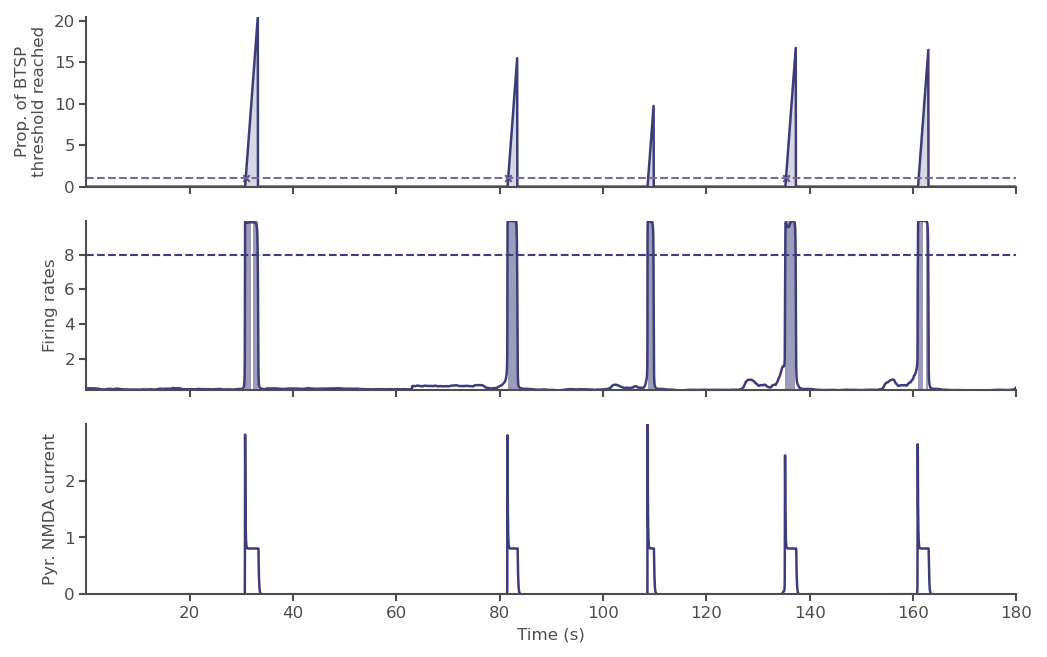

In [21]:
Pyrs.SomaCompartment.plot_BTSP_ramp();

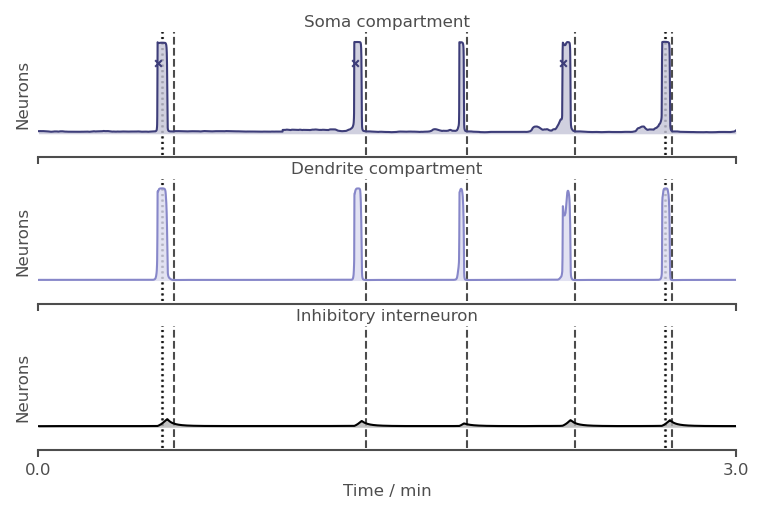

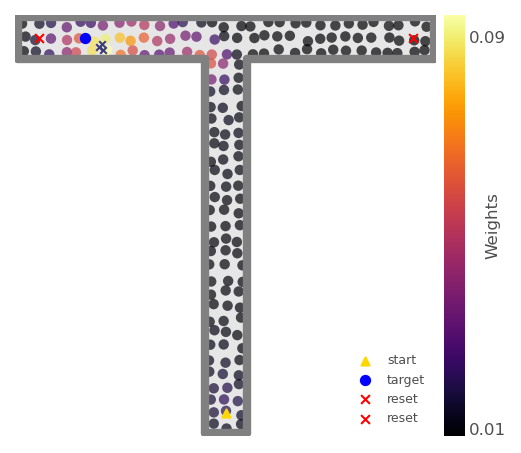

In [22]:
ax_time = Pyrs.plot_rate_timeseries(separate_axes=True, norm_by="shared_max")

fig_weights, ax_weights = plt.subplots(figsize=[3, 3])
plot_fcts.plot_2D_input_place_cell_weights(Pyrs.SomaCompartment, ax=ax_weights, s=25, plot_BTSP_events=True);

### b. Excess dendritic self-inhibiton
BTSP is unlikely to occur.

In [23]:
INHIBIT_WEIGHT = 10.0

In [24]:
DT = params_util.DT

env_params = params_util.get_env_params(environment="tmaze")

agent_params = params_util.get_agent_params(
    environment="tmaze", dt=DT, left_arm_prop=0.8
)

PC_params = params_util.get_PC_params(
    environment="tmaze", place_cell_centres="uniform"
)

Pyr_params = params_util.get_Pyr_params(
    n=1, environment="tmaze", 
    two_compartment=True, BTSP=True,
    soma_BTSP_lr_fact=BTSP_LR_FACT,
    inhibit_weight=INHIBIT_WEIGHT
)

100%|██████████████████████████████████████| 6000/6000 [00:11<00:00, 505.63it/s]


Only reached the reward 8 times (target: 12).
Trajectory lengths (7) to date: 25.71 +/- 1.93 sec each
Trajectory lengths (7) to date: 857.14 +/- 64.40 steps each


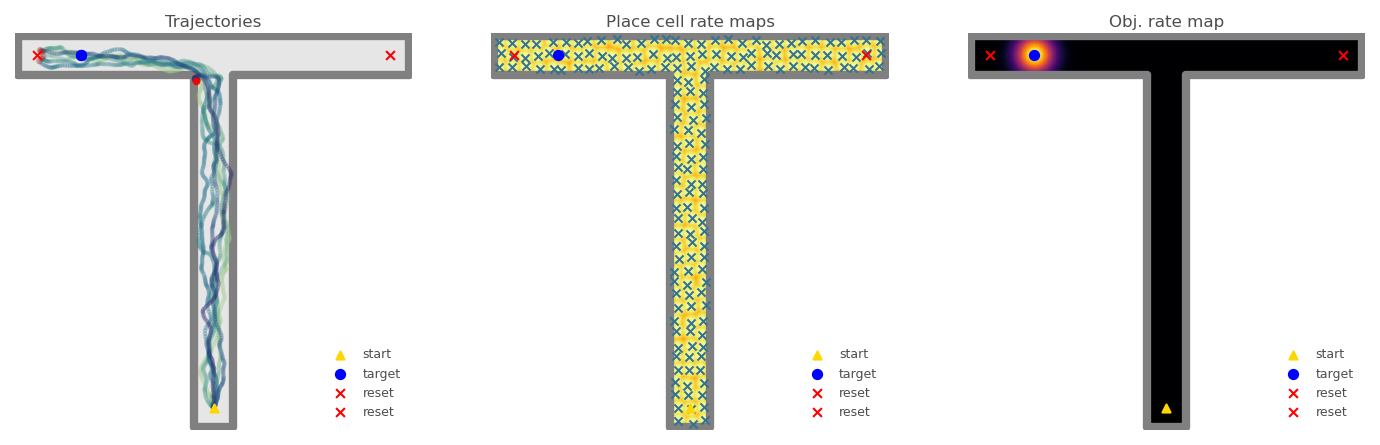

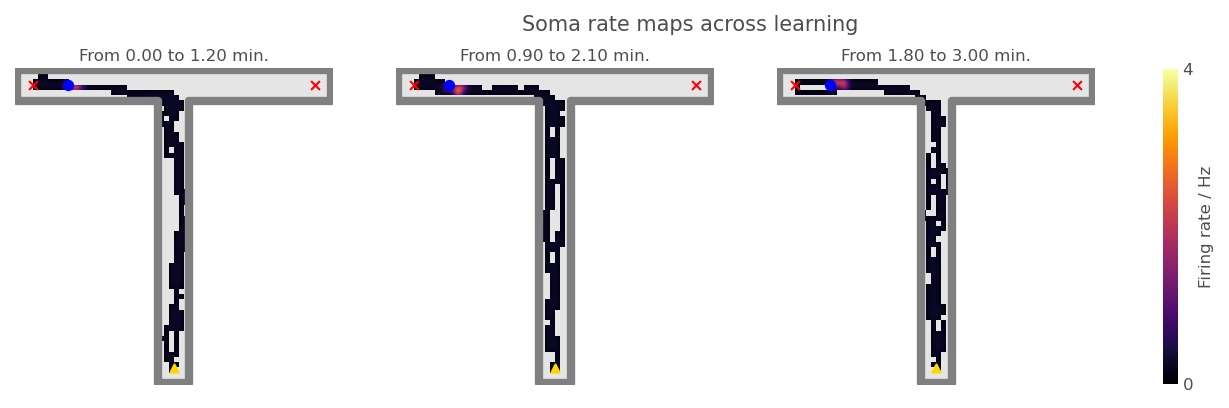

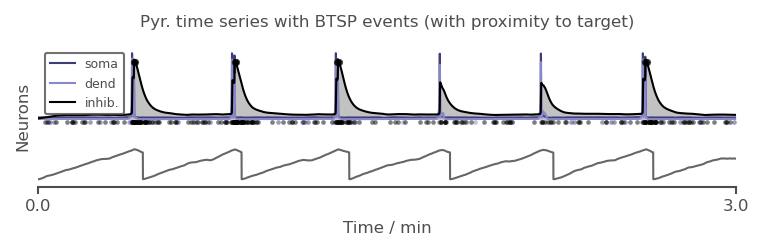

In [25]:
PC_params = params_util.get_PC_params(
    environment="tmaze", 
    n=177, # 40, # for one column and one row 
    place_cell_centres="uniform_jitter"
)

Pyrs = run_manager.learn_T_maze_BTSP(
    env_params=env_params, 
    agent_params=agent_params, 
    PC_params=PC_params, 
    Pyr_params=Pyr_params, 
    num_rewards=12, 
    max_num_steps=6000, 
    weight_recording_freq=100, 
    use_Hebbian=False,
    BTSP_after_num_target_reaches=2, # ignored if 2-compartment
    two_compartment=True
)

_, Ag, PCs, Pyrs, Objs = run_manager.extract_objects_from_Pyrs(Pyrs)

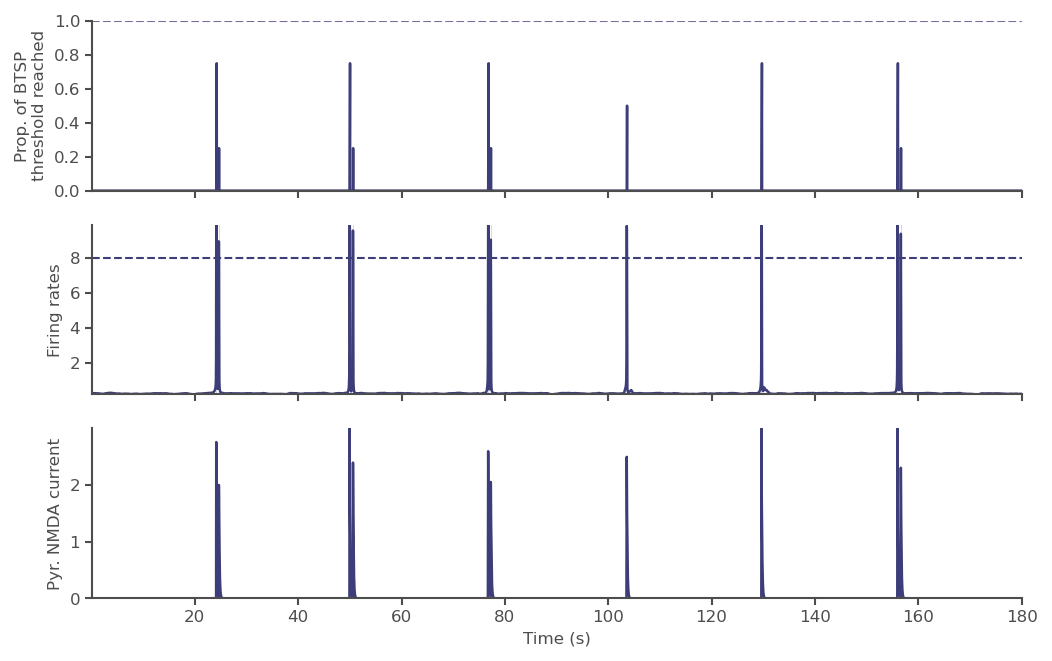

In [26]:
Pyrs.SomaCompartment.plot_BTSP_ramp();

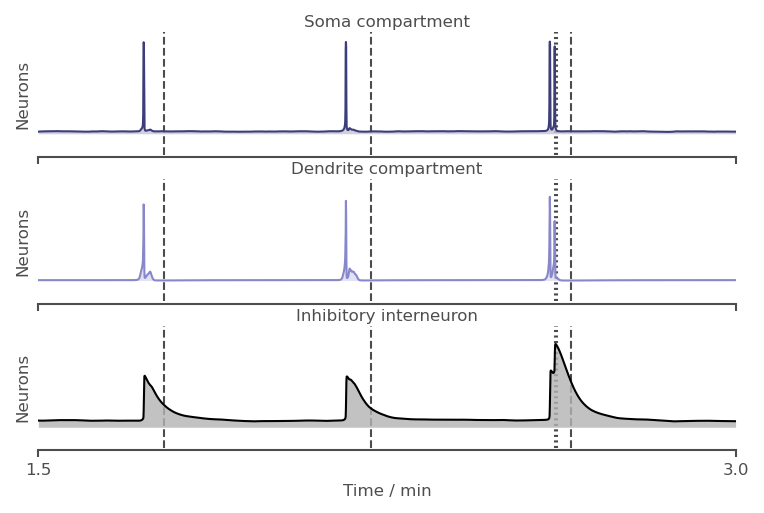

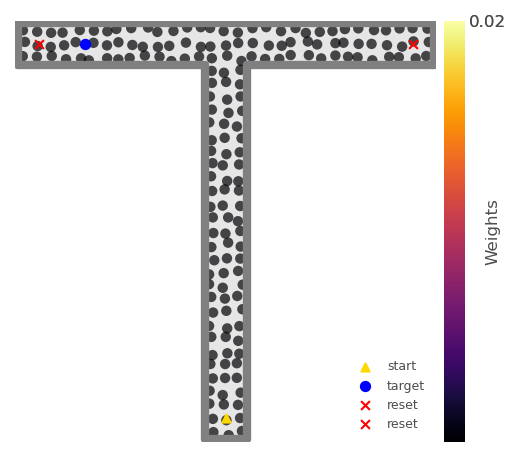

In [27]:
ax_time = Pyrs.plot_rate_timeseries(separate_axes=True, t_start=90, norm_by="shared_max")

fig_weights, ax_weights = plt.subplots(figsize=[3, 3])
plot_fcts.plot_2D_input_place_cell_weights(Pyrs.SomaCompartment, ax=ax_weights, s=25, plot_BTSP_events=True);